# Football Analysis Modular Pipeline: Step-by-Step Processor Testing

This notebook demonstrates the modular football video analysis pipeline, testing each processor step by step with real video data and visualizing the results after each stage.

In [1]:
# Import core libraries for data handling and visualization
import cv2
import numpy as np
import matplotlib.pyplot as plt
from football_ai.domain.data_models import VideoData, FrameData
from football_ai.detection.object_detection_processor import ObjectDetectionProcessor
from football_ai.rendering.renderer_processor import RendererProcessor
import os


## Load Real Data

We will load a sample football video, extract a few frames, and prepare the data for processing through the pipeline.

In [2]:
# Path to a sample video (update if needed)
video_path = 'input_videos/08fd33_4.mp4'
assert os.path.exists(video_path), f"Video not found: {video_path}"

cap = cv2.VideoCapture(video_path)
frame_rate = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / frame_rate

frames = []
for i in range(5):  # Load first 5 frames for demo
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(FrameData(
        frame_number=i,
        timestamp=cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0,
        raw_frame=frame
    ))
cap.release()

video_data = VideoData(
    video_path=video_path,
    frame_rate=frame_rate,
    resolution=(width, height),
    duration=duration,
    frames=frames
)

print(f"Loaded {len(frames)} frames from {video_path}")
model_paths = {
    'detection': 'models/detect/best.pt',
}

Loaded 5 frames from input_videos/08fd33_4.mp4


## Visualize Results After Each Processor

After each processor, we will visualize the results for the first frame to observe the changes and outputs at each stage.

OpenCV: FFMPEG: tag 0x34363268/'h264' is not supported with codec id 27 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x31637661/'avc1'
[ERROR:0@3.050] global cap_ffmpeg_impl.hpp:3133 open Could not find encoder for codec_id=27, error: Encoder not found
[ERROR:0@3.050] global cap_ffmpeg_impl.hpp:3211 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter


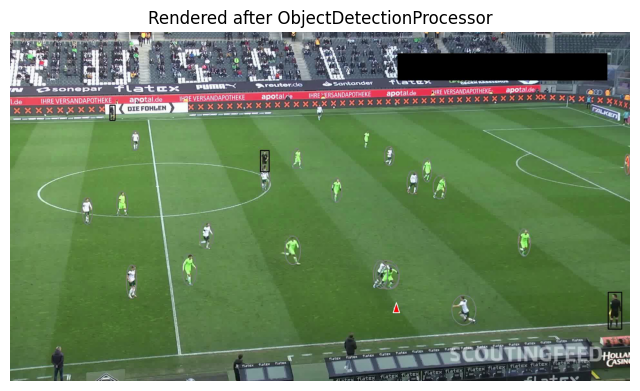

In [3]:
# 1. Object Detection
object_detection = ObjectDetectionProcessor(model_paths['detection'])
video_data_det = object_detection.process(video_data)
renderer = RendererProcessor(output_path="outputs/videos/demo_output.mp4")
rendered_det = renderer.process(video_data_det)

# read output video
output_path = "outputs/videos/demo_output.mp4"
cap_det = cv2.VideoCapture(output_path)
# Read the first frame from the output video
ret, frame_det = cap_det.read()
cap_det.release()
if not ret:
    raise RuntimeError("Failed to read the output video frame.")
# Display the first frame after object detection    

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(frame_det, cv2.COLOR_BGR2RGB))
plt.title("Rendered after ObjectDetectionProcessor")
plt.axis('off')
plt.show()


